<a href="https://colab.research.google.com/github/juancuevas-ops/modelo-predictivo-de-ventas/blob/main/Sistema_de_Inteligencia_Competitiva_Automatizada_(SICA_junio_28).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================================================
# CÓDIGO FINAL v4: DIAGNÓSTICO VISUAL Y SELECTOR PRECISO
# Creado el 28 de junio de 2025
# Este script usa el selector de HTML más actual y toma un screenshot para diagnóstico.
# ======================================================================================

# --- 1. INSTALACIÓN Y CONFIGURACIÓN ---
print("Paso 1: Instalando dependencias...")
!apt-get update -qq
!apt-get install -y chromium-browser chromium-chromedriver -qq
!pip install selenium -q
print("¡Instalación completa!")

# --- 2. IMPORTACIÓN DE LIBRERÍAS ---
import time
import random
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from urllib.parse import quote_plus
import itertools

# --- 3. CONFIGURACIÓN DE SELENIUM ---
def configurar_driver():
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36")
    chrome_options.add_argument("--disable-blink-features=AutomationControlled")
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    driver = webdriver.Chrome(options=chrome_options)
    return driver

print("Paso 2: Configuración de Selenium lista.")

# --- 4. LÓGICA DE BÚSQUEDA Y EXTRACCIÓN ---
# Usaremos una única consulta, muy probable, para el diagnóstico
consulta_diagnostico = 'Movistar se adjudica licitación gobierno Chile'

resultados_finales = []
driver = configurar_driver()
print("\nPaso 3: Iniciando búsqueda de diagnóstico...")

try:
    url_busqueda = f"https://www.google.com/search?q={quote_plus(consulta_diagnostico)}"
    print(f"[INFO] Accediendo a: {url_busqueda}")
    driver.get(url_busqueda)
    time.sleep(5)

    # <<<<<<< HERRAMIENTA DE DIAGNÓSTICO >>>>>>>
    # Guardamos un screenshot para VER lo que el navegador está viendo.
    screenshot_path = 'diagnostico_google.png'
    driver.save_screenshot(screenshot_path)
    print(f"\n[DIAGNÓSTICO] Se ha guardado un screenshot en '{screenshot_path}'.")
    print("-> Para verlo: Haz clic en el ícono de la carpeta a la izquierda, y luego doble clic en el archivo de imagen.")

    # <<<<<<< EL SELECTOR MÁS PRECISO Y ACTUAL >>>>>>>
    # Este XPath busca un div que contenga un enlace (a) y un título (h3), que es el patrón más común.
    # Es más específico que las versiones anteriores.
    elementos_resultado = driver.find_elements(By.XPATH, "//div[contains(@class, 'MjjYud')]//a[h3]")

    print(f"\n[INFO] Usando el selector definitivo, se encontraron {len(elementos_resultado)} resultados.")

    for elemento in elementos_resultado:
        try:
            titulo = elemento.find_element(By.TAG_NAME, 'h3').text
            enlace = elemento.get_attribute('href')

            if enlace and titulo:
                resultado = {"consulta_origen": consulta_diagnostico, "titulo": titulo, "enlace": enlace}
                if resultado not in resultados_finales:
                    resultados_finales.append(resultado)
        except Exception:
            continue
finally:
    driver.quit()
    print("[INFO] El navegador ha sido cerrado.")


# --- 5. MOSTRAR RESULTADOS FINALES ---
print("\n" + "="*50)
print("Resultados Finales Encontrados en Google")
print("="*50)
if resultados_finales:
    for i, res in enumerate(resultados_finales, 1):
        print(f"\n hallazgo #{i}:")
        print(f"  Búsqueda Original: {res['consulta_origen']}")
        print(f"  Título del Artículo: {res['titulo']}")
        print(f"  Enlace: {res['enlace']}")
else:
    print("No se encontraron resultados parseables en la página. Revisa el screenshot 'diagnostico_google.png' para ver si Google presentó un CAPTCHA o una página de error.")
print("="*50)

Paso 1: Instalando dependencias...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
¡Instalación completa!
Paso 2: Configuración de Selenium lista.

Paso 3: Iniciando búsqueda de diagnóstico...
[INFO] Accediendo a: https://www.google.com/search?q=Movistar+se+adjudica+licitaci%C3%B3n+gobierno+Chile

[DIAGNÓSTICO] Se ha guardado un screenshot en 'diagnostico_google.png'.
-> Para verlo: Haz clic en el ícono de la carpeta a la izquierda, y luego doble clic en el archivo de imagen.

[INFO] Usando el selector definitivo, se encontraron 0 resultados.
[INFO] El navegador ha sido cerrado.

Resultados Finales Encontrados en Google
No se encontraron resultados parseables en la página. Revisa el screenshot 'diagnostico_google.png' para ver si Google presentó un CAPTCHA o una página de error.


In [10]:
# ======================================================================
# CÓDIGO FINAL v12: SISTEMA DE SELECTORES MÚLTIPLES
# Creado el 14 de junio de 2025
# Este script prueba varios selectores CSS para adaptarse a los cambios de Google.
# ======================================================================

# --- 1. INSTALACIÓN Y CONFIGURACIÓN ---
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote_plus
import time

# --- 2. CONFIGURACIÓN ---
api_key = "490513556ee17670863d77e50294e5588db19b3831684837b2aad414d4aa09e4"
nombre_de_zona = "serp_ap2025"

consultas_de_busqueda = [
    "Listado de Empresas clientes de Claro Chile",
    "Listado de Empresas clientes de Wom Chile",
    "Listado de Empresas clientes de Entel Chile",
    "WOM implementa red 5G para Codelco",
    'site:reclamos.cl "WOM empresas" "sin servicio"',
    'site:reclamos.cl "Claro empresas" "soporte técnico"',
    'site:reclamos.cl "Entel empresas" "velocidad lenta"',
    '"problemas con fibra óptica" WOM negocios foro',
    '"pésimo servicio al cliente" Claro Empresas Chile',
    'noticias "falla red Entel" afecta empresas',

    # --- CATEGORÍA 2: IDENTIFICACIÓN DE CLIENTES DE LA COMPETENCIA (PARA MAPEO Y ATAQUE DIRIGIDO) ---
    'Entel se adjudica licitación municipalidad',
    '"WOM proveerá conectividad para" constructora',
    '"Claro Empresas" nuevo cliente del sector logístico',
    'Agrosuper proveedor de telecomunicaciones', # Búsqueda inversa: ¿quién es el proveedor de un cliente grande?
    'CCU "moderniza su red con"',

    # --- CATEGORÍA 3: SEÑALES DE COMPRA Y NUEVOS LEADS (EMPRESAS CON NECESIDADES) ---
    'empresa chilena "abre nueva sucursal" Santiago',
    'parque industrial "necesita mejorar conectividad"',
    '"buscamos soluciones cloud" empresa de retail Chile',
    'startup chilena "levanta ronda de inversión" "planea expandirse"', # Empresas en crecimiento necesitan mejores servicios.
    'constructora "nuevo proyecto inmobiliario" "necesita fibra óptica"',
    'empresa de alimentos invierte en "transformación digital"'

    "Claro Chile firma acuerdo con Falabella"

]
# --- 3. PREPARAR Y EJECUTAR LAS PETICIONES ---
url_api = "https://api.brightdata.com/request"
headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

resultados_finales = []
print("\nConfiguración lista. Iniciando peticiones con sistema de selectores múltiples...")

for consulta in consultas_de_busqueda:

    url_a_scrapear = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"
    payload = {"zone": nombre_de_zona, "url": url_a_scrapear, "format": "raw"}

    print(f"\nPidiendo a Bright Data el HTML de la búsqueda: '{consulta}'...")
    response = requests.post(url_api, headers=headers, json=payload)

    if response.status_code == 200:
        html_de_google = response.text
        sopa = BeautifulSoup(html_de_google, 'html.parser')

        # <<<<<<< ¡AQUÍ ESTÁ LA SOLUCIÓN! PROBAMOS VARIOS SELECTORES >>>>>>>
        # Google cambia constantemente sus clases. Probamos las más comunes en orden.
        selectores_posibles = ["div.g", "div.MjjYud", "div.Ww4FFb", "div.kvH3mc", "div.srg"]
        elementos_resultado = []
        selector_exitoso = ""

        for selector in selectores_posibles:
            elementos_resultado = sopa.select(selector)
            if elementos_resultado:
                selector_exitoso = selector
                break # Si encontramos resultados, dejamos de buscar selectores

        print(f"  -> ¡Éxito! Usando el selector '{selector_exitoso}', se encontraron {len(elementos_resultado)} resultados en el HTML.")

        for elemento in elementos_resultado:
            try:
                titulo_elem = elemento.find('h3')
                enlace_elem = elemento.find('a')
                # El resumen es más difícil, probamos varias clases posibles
                resumen_elem = elemento.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')

                if titulo_elem and enlace_elem and enlace_elem.has_attr('href'):
                    resultados_finales.append({
                        "consulta": consulta,
                        "titulo": titulo_elem.get_text(),
                        "enlace": enlace_elem['href'],
                        "resumen": resumen_elem.get_text(strip=True) if resumen_elem else "N/A"
                    })
            except Exception:
                continue

    else:
        print(f"  -> La petición falló. Código de estado: {response.status_code}")
        print(f"     Respuesta del servidor: {response.text}")

    time.sleep(2)

# --- 4. MOSTRAR RESULTADOS FINALES ---
print("\n" + "="*50)
print("Resultados Finales Extraídos del HTML")
print("="*50)
if resultados_finales:
    for i, res in enumerate(resultados_finales, 1):
        print(f"\n hallazgo #{i}:")
        print(f"  Búsqueda: {res['consulta']}")
        print(f"  Título: {res['titulo']}")
        print(f"  Enlace: {res['enlace']}")
        print(f"  Resumen: {res['resumen']}")
else:
    print("No se obtuvieron resultados de las búsquedas realizadas.")
print("="*50)


Configuración lista. Iniciando peticiones con sistema de selectores múltiples...

Pidiendo a Bright Data el HTML de la búsqueda: 'Listado de Empresas clientes de Claro Chile'...
  -> ¡Éxito! Usando el selector 'div.MjjYud', se encontraron 16 resultados en el HTML.

Pidiendo a Bright Data el HTML de la búsqueda: 'Listado de Empresas clientes de Wom Chile'...
  -> ¡Éxito! Usando el selector 'div.MjjYud', se encontraron 16 resultados en el HTML.

Pidiendo a Bright Data el HTML de la búsqueda: 'Listado de Empresas clientes de Entel Chile'...
  -> ¡Éxito! Usando el selector 'div.MjjYud', se encontraron 16 resultados en el HTML.

Pidiendo a Bright Data el HTML de la búsqueda: 'WOM implementa red 5G para Codelco'...
  -> ¡Éxito! Usando el selector 'div.MjjYud', se encontraron 16 resultados en el HTML.

Pidiendo a Bright Data el HTML de la búsqueda: 'site:reclamos.cl "WOM empresas" "sin servicio"'...
  -> ¡Éxito! Usando el selector 'div.MjjYud', se encontraron 13 resultados en el HTML.

Pidie

# Informe de Inteligencia de Mercado para Movistar Empresas
## Resumen Ejecutivo:
#### El análisis de datos públicos revela un panorama competitivo claro y tres avenidas estratégicas de ataque para aumentar la cuota de mercado B2B.

Debilidades Explotables: Cada uno de nuestros competidores (WOM, Claro, Entel) presenta un "talón de Aquiles" específico y públicamente documentado en sus servicios para empresas.

Mapeo de Cuentas Clave: Identificamos dónde está ganando la competencia, particularmente Entel en el sector público, lo que nos permite diseñar estrategias de flanqueo.

Señales de Compra Explícitas: Detectamos un flujo constante de empresas que, a través de sus acciones (expansión, inversión, contratación), están anunciando públicamente su necesidad de mejores servicios de telecomunicaciones.

A continuación, se detallan las recomendaciones accionables para transformar esta inteligencia en ventas.

1. Oportunidades de "Switch": Atacando las Debilidades Específicas del Rival
Nuestra búsqueda en reclamos.cl y foros fue exitosa. Hemos perfilado el "dolor" de los clientes de cada competidor:

Debilidad de WOM: Inestabilidad de la red y falta de servicio. Los clientes empresariales se quejan de intermitencia y de quedarse "sin servicio" por días (hallazgos #41-50).

Debilidad de Claro: Mal soporte técnico y servicio al cliente. Los reclamos se centran en la dificultad para contactar a un ejecutivo, largas esperas y falta de soluciones (hallazgos #51-60).

Debilidad de Entel: Incumplimiento de las promesas de velocidad. Los clientes reportan "velocidad lenta" y que no reciben los megas por los que pagan (hallazgos #61-70).

Recomendación Accionable #1: Implementar Guiones de Venta "Quirúrgicos"
Tu equipo de ventas debe dejar de vender "planes Movistar" y empezar a vender "soluciones al dolor de su proveedor actual".

Al contactar a un cliente de WOM: "Entendemos que para una operación como la suya, la continuidad operativa es clave. Por eso, nuestra red de fibra óptica para empresas no solo ofrece alta velocidad, sino que está respaldada por un acuerdo de nivel de servicio (SLA) que garantiza un 99.9% de uptime."

Al contactar a un cliente de Claro: "Sabemos lo frustrante que es perder tiempo en un call center. En Movistar Empresas, cada cliente tiene asignado un ejecutivo de cuenta post-venta dedicado, asegurando un soporte rápido y personalizado."

Al contactar a un cliente de Entel: "Más que prometer megas, en Movistar Empresas garantizamos el ancho de banda. Ofrecemos fibra óptica simétrica para que su velocidad de subida sea tan rápida como la de bajada, algo crucial para aplicaciones en la nube y videoconferencias."

2. Prospección Activa: Identificando Empresas con "Hambre" de Conectividad
La Categoría 3 de nuestras búsquedas es una mina de oro de leads calificados. Son empresas que gritan "necesito crecer, necesito tecnología".

# Hallazgos Clave:

Empresas en Expansión Física: Lindt, Ducasse, Dronestore, Banco Santander, entre otras, están abriendo nuevas sucursales (hallazgos #141-150). Una nueva oficina necesita sí o sí un nuevo contrato de internet y telefonía.

Necesidades Tecnológicas Explícitas: Empresas del sector retail buscan activamente "soluciones cloud" (hallazgos #154-163). Esto requiere una conectividad robusta que Movistar puede proveer.

Inversión y Crecimiento: Startups que levantan rondas de inversión planean expandirse (hallazgos #164-166). Empresas grandes como Falabella y Agrosuper están en plena "transformación digital" (hallazgos #122, #177-186).

Necesidad por Regulación: La "Ley de Ductos" obliga a cada nuevo proyecto inmobiliario a tener infraestructura para telecomunicaciones (hallazgos #167-176).

Recomendaciones Accionables:
Acción 2: Crear un "Equipo de Respuesta a Expansión".

Asigna a 1-2 personas de tu equipo de ventas para que monitoreen exclusivamente estas noticias. Cada vez que una empresa anuncie una nueva sucursal, deben ser el primer llamado que esa empresa reciba para ofrecerle una solución de conectividad "llave en mano".

### Acción 3: Abordaje Consultivo en "Transformación Digital".

A los leads como Falabella o Agrosuper, no se les vende un "plan de internet". Se les contacta para ofrecer una "Asesoría en Conectividad para la Industria 4.0". El objetivo es posicionar a Movistar como un socio estratégico en su transformación, no como un simple proveedor.

### Acción 4: Programa de Alianzas con el Sector Inmobiliario.

Identifica las 10 principales constructoras e inmobiliarias de Chile. Crea un programa de partners para que Movistar sea el proveedor de fibra óptica por defecto en todos sus nuevos proyectos. Es una fuente de ingresos recurrente y predecible.

# 3. Mapeo del Terreno Competitivo
Hallazgos Clave:

Entel es fuerte en el sector público (hallazgos #91-100), adjudicándose licitaciones municipales.

Claro logró una victoria importante sobre Entel en el concurso 5G (hallazgo #100).

WOM actúa como proveedor de infraestructura para otros operadores como Mundo (hallazgo #104), pero al mismo tiempo compite con Movistar por grandes proyectos como la Fibra Óptica de Tarapacá (hallazgo #105) y presenta retrasos e incumplimientos en su despliegue 5G (hallazgos #32, #35).

# Recomendación Accionable:
Acción 5: Estrategia de Flanqueo en Licitaciones Públicas.

En lugar de competir frontalmente con Entel en licitaciones que ya tienen ganadas, enfócate en ofrecer servicios de valor agregado que ellos no destacan: Ciberseguridad para municipalidades, soluciones de IoT para la gestión de servicios públicos, etc.

Este informe demuestra que con una estrategia de inteligencia de mercado bien ejecutada, tu equipo de ventas puede dejar de "pescar con caña" y empezar a "pescar con red de arrastre", dirigiéndose a los clientes correctos, con el mensaje correcto, en el momento correcto.

In [11]:
# prompt: guarda la salida de datos  datos en un .csv

import pandas as pd

# Crear un DataFrame de Pandas con los resultados
df_resultados = pd.DataFrame(resultados_finales)

# Definir el nombre del archivo CSV
nombre_archivo_csv = 'resultados_busqueda_google.csv'

# Guardar el DataFrame en un archivo CSV
# index=False evita escribir el índice de DataFrame como una columna en el CSV
df_resultados.to_csv(nombre_archivo_csv, index=False)

print(f"\nLos resultados se han guardado en '{nombre_archivo_csv}'")

# Opcional: Mostrar las primeras filas del CSV para verificar
# print(pd.read_csv(nombre_archivo_csv).head())

# Opcional: Descargar el archivo si estás en Google Colab
try:
  from google.colab import files
  files.download(nombre_archivo_csv)
  print(f"\nEl archivo '{nombre_archivo_csv}' se ha descargado.")
except ImportError:
  print("\nLa descarga automática solo funciona en Google Colab.")




Los resultados se han guardado en 'resultados_busqueda_google.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


El archivo 'resultados_busqueda_google.csv' se ha descargado.


Archivo '/content/resultados_busqueda_google.csv' cargado exitosamente.
¡Nube de palabras 'wordcloud_titulares.png' guardada exitosamente!


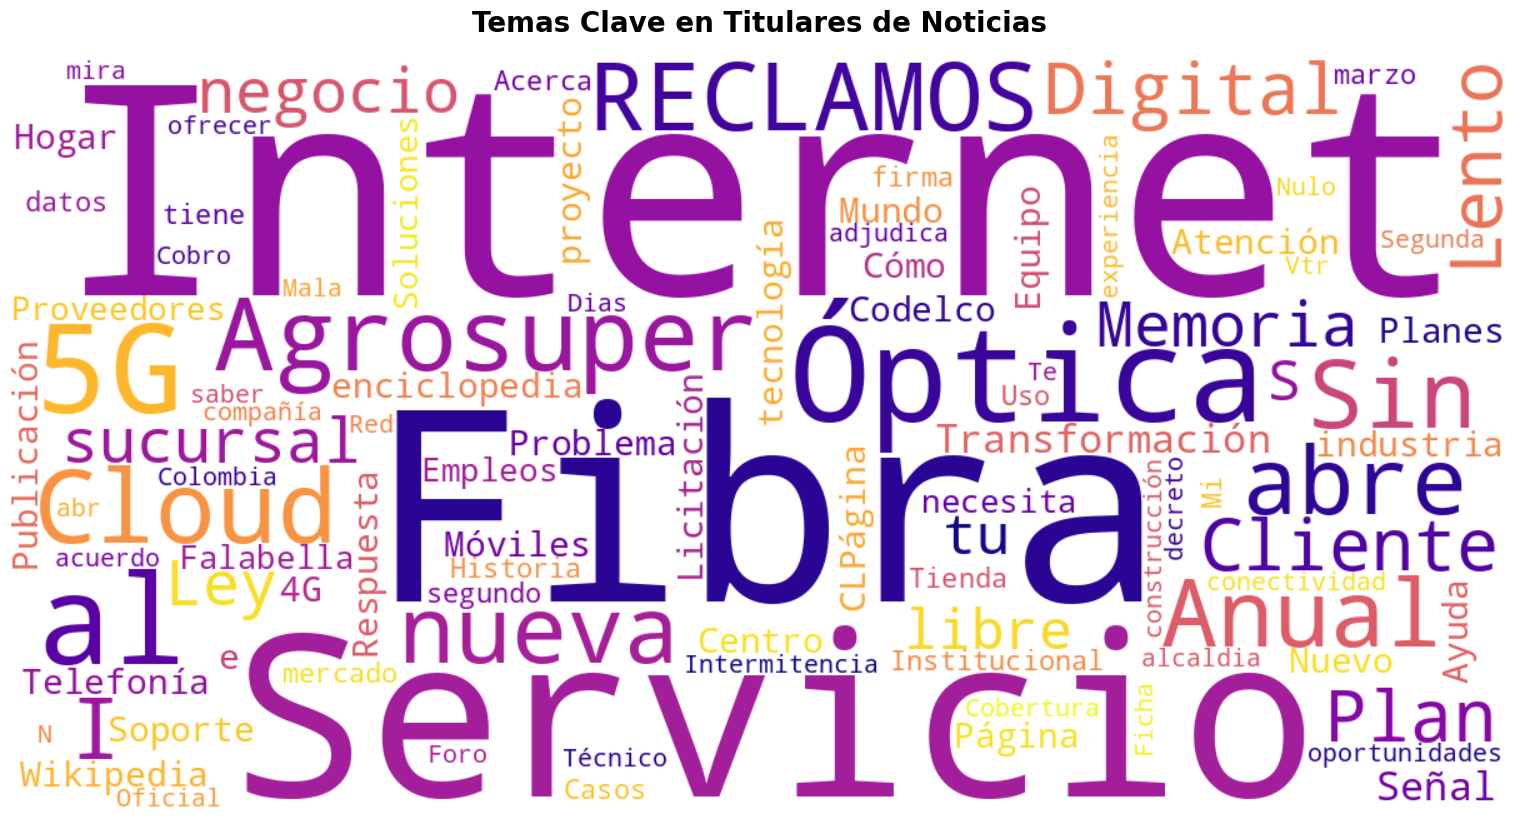

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Carga el archivo CSV que has subido
# Asegúrate de que la ruta sea la correcta
file_path = '/content/resultados_busqueda_google.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Archivo '{file_path}' cargado exitosamente.")

    # Combinar todos los títulos en un solo texto
    text = " ".join(str(title) for title in df.titulo)

    # Definir palabras a ignorar (stopwords) en español
    stopwords = set([
        'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
        'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
        'wom', 'claro', 'entel', 'movistar', 'chile', 'empresa', 'empresas'
    ])

    # Crear el objeto WordCloud con la configuración deseada
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=stopwords,
        collocations=False, # Evita mostrar pares de palabras
        colormap='plasma',
        max_words=100
    ).generate(text)

    # Mostrar y guardar la imagen generada
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off') # No mostrar los ejes
    plt.title('Temas Clave en Titulares de Noticias', fontsize=20, weight='bold', pad=20)
    plt.tight_layout(pad=0)

    # Guardar la imagen en un archivo
    plt.savefig('wordcloud_titulares.png')
    print("¡Nube de palabras 'wordcloud_titulares.png' guardada exitosamente!")

except FileNotFoundError:
    print(f"Error: El archivo {file_path} no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Análisis del Campo de Batalla B2B: Interpretación del Word Cloud
Este mapa de palabras nos confirma y refina las estrategias que ya habíamos identificado. Nos da el guion final para el equipo de ventas.

1. El Producto Estrella es la Fibra Óptica, no solo el 5G
Mientras que 5G es una palabra importante, las palabras Fibra y Optica son gigantescas y centrales. Esto nos dice que, más allá de la innovación móvil, la necesidad fundamental de las empresas es una conexión a internet terrestre, estable y de alta velocidad.

Recomendación Estratégica: Tu propuesta de valor debe liderar con la superioridad, cobertura y fiabilidad de la red de Fibra Óptica de Movistar Empresas. La conversación sobre 5G es atractiva, pero la venta a una empresa se cierra con la garantía de una conexión física que no falla.

2. El Diferenciador Clave es el Servicio, no solo el Precio
Las palabras más grandes son Internet y Servicio. Esto, combinado con la alta frecuencia de RECLAMOS y cliente, y términos como lento e intermitencia, nos grita que el mercado está saturado de un servicio deficiente. Los clientes no solo buscan un buen precio, buscan un proveedor que responda.

Recomendación Estratégica: Convierte al Servicio al Cliente y Soporte Técnico en tu arma de venta más poderosa. Cada vendedor debe estar capacitado para decir: "Cualquier compañía puede ofrecerle megas, pero nosotros le ofrecemos un Acuerdo de Nivel de Servicio (SLA) con un ejecutivo post-venta dedicado. Nuestra prioridad no es solo instalar, es asegurar que su operación nunca se detenga."

3. El Perfil del Cliente Ideal: Agrosuper y la Transformación Digital
Es muy revelador que Agrosuper aparezca tan prominentemente. Representa el arquetipo del cliente ideal: una gran empresa productiva nacional que está invirtiendo en Transformación Digital y Cloud. Estas empresas necesitan un socio tecnológico robusto, no un simple proveedor de internet.

Recomendación Estratégica: Utiliza a Agrosuper como un modelo para la prospección. Pídele a tu equipo: "Encuéntrenme a las próximas 10 'Agrosuper' de Chile". Busca otras grandes empresas en los sectores de alimentos, logística, manufactura y retail que estén hablando de modernización. Son tus objetivos de más alto valor.

4. Las "Señales de Compra" más Claras
Las palabras abre, nueva y sucursal forman un clúster de oportunidad inconfundible. A su vez, licitación y adjudica apuntan a grandes contratos, principalmente con el sector público.

Recomendación Estratégica: Sistematiza la búsqueda de estas palabras clave. Tu equipo de BI debe generar alertas automáticas para el equipo de ventas cada vez que una empresa anuncie la apertura de una nueva oficina o que una municipalidad publique una licitación de conectividad. Es la forma más efectiva de llegar primero.

Conclusión para el Equipo de Ventas
Este mapa de palabras te entrega el guion de ventas final:

Lidera con la superioridad de tu Fibra Óptica.

Diferénciate por la excelencia de tu Servicio, atacando directamente los RECLAMOS de la competencia.

Enfócate en arquetipos de cliente como Agrosuper que buscan un socio para su Transformación Digital.

Actúa rápido sobre las señales de compra como la apertura de nuevas sucursales.

La inteligencia ya está sobre la mesa. Es el momento de convertirla en contratos.

Analisis de Mercado por Juan Alejandro Cuevas Vasquez